In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

# Módulo 3 y 4: Scikit-Learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Cargar dataset procesado en la fase anterior
df = pd.read_csv('../Data/processed/startups_cleaned_2026.csv')
print(f"Dataset cargado con éxito: {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head(2)

Dataset cargado con éxito: 25000 filas y 21 columnas.


,Company_ID,Domain,Founding_Year,Country,City,Funding_Stage,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,...,Peak_Headcount_2023,Layoffs_2024_2025,Current_Headcount_2026,Investor_Tier,AI_Adoption_Level,Acquisition_Status,Valuation_Multiple,Burn_Multiple,Layoff_Ratio,Runway_Health
0,B730AD52,HealthTech,2014,Canada,Montreal,Seed,1.64,17.81,1.46,0.33,...,23,0,23,Tier 3 (Angel/Seed),High,Independent,12.198630,2.71,0.0000,Crítico (< 6m)
1,65A5F690,Web3/Crypto,2014,China,Beijing,Pre-IPO,103.87,949.16,32.77,2.42,...,242,146,96,Tier 3 (Angel/Seed),High,Closed,28.964297,0.89,0.6033,Saludable (> 18m)


In [2]:
# Crear descripción textual de la startup combinando columnas categóricas
df['Text_Profile'] = (
    "Startup in " + df['Domain'] + 
    " located in " + df['City'] + ", " + df['Country'] + 
    " backed by " + df['Investor_Tier'] + 
    " with " + df['AI_Adoption_Level'] + " AI adoption."
)

print("--- Ejemplo de Perfil Textual ---")
print(df['Text_Profile'].iloc[0])

# Crear variable objetivo binaria: 1 si está cerrada (Closed), 0 en caso contrario
df['Is_Closed'] = np.where(df['Acquisition_Status'] == 'Closed', 1, 0)
print(f"\nDistribución de la Variable Objetivo ('Is_Closed'):")
print(df['Is_Closed'].value_counts(normalize=True))

--- Ejemplo de Perfil Textual ---
Startup in HealthTech located in Montreal, Canada backed by Tier 3 (Angel/Seed) with High AI adoption.

Distribución de la Variable Objetivo ('Is_Closed'):
Is_Closed
0    0.79652
1    0.20348
Name: proportion, dtype: float64


In [3]:
# 1. Definir columnas numéricas, categóricas y de texto
numeric_features = [
    'Total_Funding_USD_Millions', 'Valuation_USD_Millions', 
    'Revenue_ARR_Millions', 'Monthly_Burn_Rate_Millions', 
    'Runway_Months_2024', 'Burn_Multiple'
]

categorical_features = ['Domain', 'Investor_Tier', 'AI_Adoption_Level', 'Funding_Stage']
text_feature = 'Text_Profile'

# 2. Definir Preprocesadores por tipo de columna
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

text_transformer = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(max_features=50, stop_words='english'))
])

# 3. Combinar todos los preprocesadores en un ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('text', text_transformer, text_feature)
    ]
)

# 4. Dividir Datos en Entrenamiento (Train) y Prueba (Test)
X = df[numeric_features + categorical_features + [text_feature]]
y = df['Is_Closed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Datos de Entrenamiento: {X_train.shape[0]} samples | Datos de Prueba: {X_test.shape[0]} samples")

Datos de Entrenamiento: 20000 samples | Datos de Prueba: 5000 samples


In [4]:
# Crear el Pipeline Final (Preprocesamiento + Modelo)
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1))
])

# Entrenar el Pipeline
print("Entrenando modelo de Machine Learning...")
model_pipeline.fit(X_train, y_train)

# Predicciones
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:, 1]

# Reporte de Clasificación
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

Entrenando modelo de Machine Learning...

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.81      0.97      0.88      3983
           1       0.44      0.10      0.16      1017

    accuracy                           0.79      5000
   macro avg       0.63      0.53      0.52      5000
weighted avg       0.73      0.79      0.73      5000

ROC-AUC Score: 0.5904


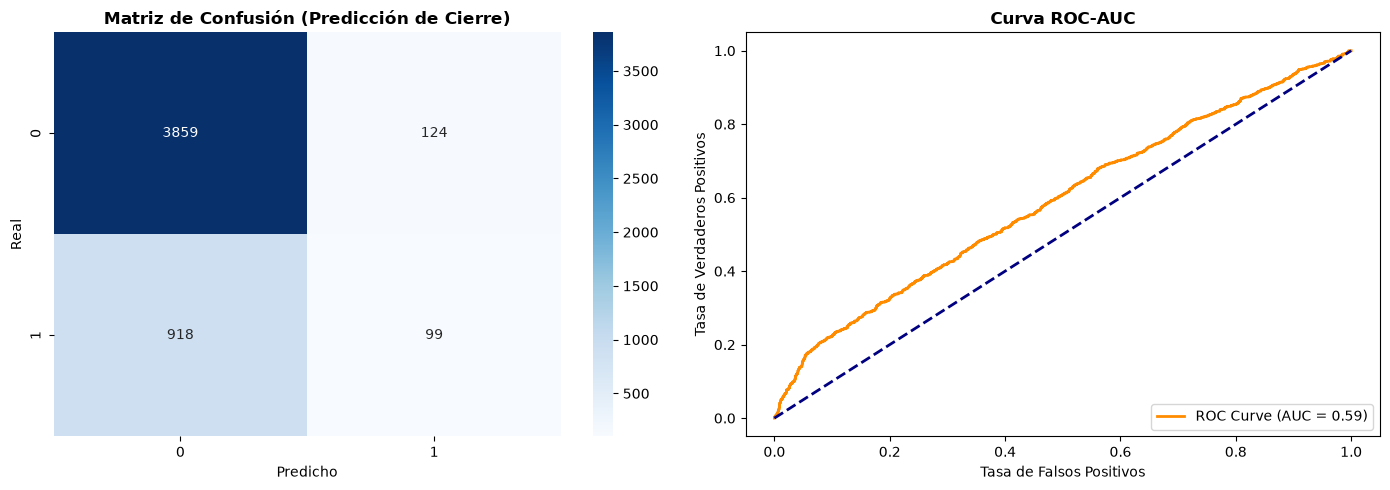

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusión (Predicción de Cierre)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_proba):.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title('Curva ROC-AUC', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].legend(loc='lower right')

plt.tight_layout()
os.makedirs('../Images', exist_ok=True)
plt.savefig('../Images/model_evaluation_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
# Preprocesar datos solo numéricos para Clustering
X_scaled = StandardScaler().fit_transform(df[numeric_features].fillna(0))

# Entrenar K-Means con 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster_Perfil'] = kmeans.fit_predict(X_scaled)

print("--- Tamaño de cada Segmento/Cluster ---")
print(df['Cluster_Perfil'].value_counts())

# Guardar el Pipeline entrenado en la carpeta 'models/'
os.makedirs('../models', exist_ok=True)
joblib.dump(model_pipeline, '../models/startup_risk_pipeline.pkl')
print("\n✅ Pipeline de Machine Learning guardado con éxito en 'models/startup_risk_pipeline.pkl'")

--- Tamaño de cada Segmento/Cluster ---
Cluster_Perfil
1    16045
0     8710
2      245
Name: count, dtype: int64

✅ Pipeline de Machine Learning guardado con éxito en 'models/startup_risk_pipeline.pkl'
